In [155]:
import pandas as pd
import numpy as np
import missingno as msno
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pl.Config.set_tbl_cols(-1)
pl.Config.set_float_precision(5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.5f}'.format)

In [156]:
df = pl.read_csv('digital_burnout_productivity_dataset_5M.csv')

## EDA

In [157]:
print(df.shape)
df.head(10)

(5000000, 34)


user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
i64,i64,str,str,str,f64,f64,f64,i64,i64,i64,i64,i64,f64,i64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,i64,str,i64,i64,str
1,56,"""Content Creator""","""Office""","""Entertainment-Centric""",8.80000,5.00000,1.20000,41,112,49,1,3,6.00000,67,92,2,5.90000,10,6,1.60000,10,5,2.80000,3,4,8.00000,10,4,8,"""Balanced""",46,100,"""High"""
2,46,"""Student""","""Hybrid""","""Work-Centric""",10.30000,2.20000,2.40000,119,168,153,1,9,4.60000,75,74,3,5.60000,7,5,1.10000,5,10,3.20000,7,6,5.00000,7,9,7,"""Balanced""",57,96,"""High"""
3,32,"""Software Engineer""","""Remote""","""Balanced""",6.50000,4.60000,1.00000,121,199,234,1,5,null,70,96,7,5.50000,8,6,1.10000,4,1,2.30000,9,6,8.00000,5,2,6,"""Balanced""",29,79,"""High"""
4,25,"""Designer""","""Office""","""Balanced""",9.60000,1.20000,0.10000,85,122,177,1,9,2.90000,107,60,3,6.10000,5,1,1.70000,1,4,3.80000,10,5,6.00000,4,5,3,"""Burnout""",57,63,"""Medium"""
5,38,"""Analyst""","""Hybrid""","""Work-Centric""",13.30000,1.60000,1.90000,221,73,91,1,9,2.80000,72,73,9,7.90000,1,3,1.80000,4,8,3.00000,1,1,4.00000,7,9,7,"""Focused""",64,89,"""High"""
6,56,"""Content Creator""","""Office""","""Balanced""",10.30000,4.00000,2.70000,192,89,188,1,8,6.10000,97,43,6,6.70000,3,0,0.80000,5,5,2.60000,1,0,9.00000,7,9,6,"""Distracted""",97,79,"""High"""
7,36,"""Student""","""Remote""","""Balanced""",9.40000,7.40000,3.90000,245,252,294,0,7,0.00000,45,41,2,8.80000,3,1,1.40000,1,7,2.50000,3,6,3.00000,5,8,8,"""Focused""",23,25,"""Low"""
8,40,"""Designer""","""Office""","""Work-Centric""",4.40000,3.90000,2.30000,238,38,183,0,1,3.50000,32,84,1,7.20000,1,5,1.20000,7,9,2.70000,8,0,6.00000,1,2,7,"""Burnout""",43,62,"""Medium"""
9,28,"""Content Creator""","""Hybrid""","""Balanced""",10.40000,0.60000,1.90000,132,24,212,1,0,3.60000,66,90,10,7.70000,9,3,1.20000,2,8,1.60000,5,3,8.00000,7,1,7,"""Balanced""",31,100,"""High"""


In [158]:
print(set(df['occupation'].unique()))
print(set(df['work_mode'].unique()))
print(set(df['device_usage_type'].unique()))
print(set(df['mental_state'].unique()))
print(set(df['productivity_category'].unique()))


{'Freelancer', 'Manager', 'Analyst', 'Software Engineer', 'Content Creator', 'Student', 'Designer'}
{'Remote', 'Hybrid', 'Office'}
{'Balanced', 'Entertainment-Centric', 'Work-Centric'}
{'Burnout', 'Balanced', 'Focused', 'Distracted'}
{'Medium', 'High', 'Low'}


In [159]:
int_cols = df.select(pl.col(pl.Int64)).columns
float_cols = df.select(pl.col(pl.Float64)).columns


bad_cols = [
    col for col in float_cols
    if df[col].min() < np.finfo(np.float16).min
    or df[col].max() > np.finfo(np.float16).max
]

print(bad_cols)

[]


In [160]:
df = df.with_columns(
    pl.col(pl.String).cast(pl.Categorical)
)

In [161]:
df.schema

Schema([('user_id', Int64),
        ('age', Int64),
        ('occupation', Categorical),
        ('work_mode', Categorical),
        ('device_usage_type', Categorical),
        ('daily_screen_time', Float64),
        ('social_media_hours', Float64),
        ('doomscrolling_duration', Float64),
        ('app_switch_frequency', Int64),
        ('notification_count', Int64),
        ('smartphone_unlocks', Int64),
        ('late_night_device_usage', Int64),
        ('focus_sessions', Int64),
        ('deep_work_hours', Float64),
        ('distraction_frequency', Int64),
        ('task_completion_rate', Int64),
        ('concentration_score', Int64),
        ('sleep_hours', Float64),
        ('sleep_quality', Int64),
        ('caffeine_intake', Int64),
        ('physical_activity', Float64),
        ('stress_level', Int64),
        ('workspace_quality', Int64),
        ('meeting_hours', Float64),
        ('internet_stability', Int64),
        ('remote_work_days', Int64),
        ('motivatio

In [162]:
df.describe()

statistic,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str
"""count""",5000000.00000,5000000.00000,"""5000000""","""5000000""","""5000000""",5000000.00000,4900000.00000,5000000.00000,5000000.00000,5000000.00000,5000000.00000,5000000.00000,5000000.00000,4900000.00000,5000000.00000,5000000.00000,5000000.00000,4900000.00000,5000000.00000,5000000.00000,5000000.00000,5000000.00000,5000000.00000,5000000.00000,5000000.00000,5000000.00000,4900000.00000,5000000.00000,5000000.00000,5000000.00000,"""5000000""",5000000.00000,5000000.00000,"""5000000"""
"""null_count""",0.00000,0.00000,"""0""","""0""","""0""",0.00000,100000.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,100000.00000,0.00000,0.00000,0.00000,100000.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,100000.00000,0.00000,0.00000,0.00000,"""0""",0.00000,0.00000,"""0"""
"""mean""",2500000.50000,38.49935,null,null,null,8.00101,3.51765,1.83464,129.49810,209.43795,157.04311,0.64999,4.50051,3.03533,60.03352,69.99729,5.50123,6.50067,5.50262,3.50045,1.23781,5.49949,5.49845,2.52965,5.50041,3.00061,5.49945,5.49956,5.50201,5.50090,null,48.58374,71.44397,null
"""std""",1443375.81731,12.12046,null,null,null,2.49480,1.75943,1.13221,69.28145,109.66456,82.28162,0.47697,2.87272,1.72507,34.35011,17.60124,2.87177,1.47339,2.87199,2.29143,0.83012,2.87143,2.87178,1.43784,2.87305,1.99989,2.87192,2.87202,2.87182,2.87248,null,22.07203,21.49899,null
"""min""",1.00000,18.00000,null,null,null,1.00000,0.00000,0.00000,10.00000,20.00000,15.00000,0.00000,0.00000,0.00000,1.00000,40.00000,1.00000,3.00000,1.00000,0.00000,0.00000,1.00000,1.00000,0.00000,1.00000,0.00000,1.00000,1.00000,1.00000,1.00000,null,0.00000,0.00000,null
"""25%""",1250001.00000,28.00000,null,null,null,6.30000,2.30000,1.00000,69.00000,114.00000,86.00000,0.00000,2.00000,1.80000,30.00000,55.00000,3.00000,5.50000,3.00000,2.00000,0.60000,3.00000,3.00000,1.50000,3.00000,1.00000,3.00000,3.00000,3.00000,3.00000,null,33.00000,56.00000,null
"""50%""",2500001.00000,38.00000,null,null,null,8.00000,3.50000,1.80000,129.00000,209.00000,157.00000,1.00000,5.00000,3.00000,60.00000,70.00000,6.00000,6.50000,6.00000,4.00000,1.20000,5.00000,5.00000,2.50000,6.00000,3.00000,5.00000,5.00000,6.00000,6.00000,null,48.00000,73.00000,null
"""75%""",3750000.00000,49.00000,null,null,null,9.70000,4.70000,2.60000,190.00000,304.00000,228.00000,1.00000,7.00000,4.20000,90.00000,85.00000,8.00000,7.50000,8.00000,6.00000,1.80000,8.00000,8.00000,3.50000,8.00000,5.00000,8.00000,8.00000,8.00000,8.00000,null,64.00000,90.00000,null
"""max""",5000000.00000,59.00000,null,null,null,18.00000,12.00000,7.90000,249.00000,399.00000,299.00000,1.00000,9.00000,11.80000,119.00000,100.00000,10.00000,10.00000,10.00000,7.00000,5.00000,10.00000,10.00000,10.00000,10.00000,6.00000,10.00000,10.00000,10.00000,10.00000,null,100.00000,100.00000,null


In [163]:
df.null_count()

user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,100000,0,0,0,0,0,0,100000,0,0,0,100000,0,0,0,0,0,0,0,0,100000,0,0,0,0,0,0,0


In [164]:
df.filter(pl.any_horizontal(pl.all().is_null()))


user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
i64,i64,cat,cat,cat,f64,f64,f64,i64,i64,i64,i64,i64,f64,i64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,i64,cat,i64,i64,cat
3,32,"""Software Engineer""","""Remote""","""Balanced""",6.50000,4.60000,1.00000,121,199,234,1,5,null,70,96,7,5.50000,8,6,1.10000,4,1,2.30000,9,6,8.00000,5,2,6,"""Balanced""",29,79,"""High"""
43,43,"""Content Creator""","""Hybrid""","""Balanced""",1.60000,null,3.20000,210,174,119,1,0,2.10000,115,82,2,8.50000,10,6,1.10000,10,8,3.60000,7,3,5.00000,8,8,5,"""Focused""",70,53,"""Medium"""
50,31,"""Analyst""","""Remote""","""Balanced""",7.80000,2.60000,1.70000,233,54,216,0,7,6.00000,76,42,7,6.10000,9,3,1.60000,1,3,4.90000,10,2,null,7,1,2,"""Focused""",12,100,"""High"""
59,46,"""Software Engineer""","""Remote""","""Work-Centric""",8.30000,2.10000,2.50000,58,214,239,1,9,null,81,69,9,3.50000,4,0,1.50000,4,8,4.20000,4,6,9.00000,2,1,9,"""Balanced""",40,100,"""High"""
71,57,"""Content Creator""","""Office""","""Work-Centric""",10.30000,null,2.00000,209,242,176,1,2,7.20000,109,98,3,6.80000,10,5,1.40000,7,7,3.20000,3,1,2.00000,4,10,2,"""Focused""",42,100,"""High"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4999895,26,"""Student""","""Office""","""Entertainment-Centric""",3.60000,2.90000,4.80000,198,248,242,1,5,null,77,81,7,5.70000,1,0,0.70000,4,5,1.40000,10,1,1.00000,1,2,1,"""Burnout""",64,43,"""Low"""
4999936,52,"""Freelancer""","""Remote""","""Balanced""",2.70000,1.50000,0.00000,146,370,162,1,2,2.00000,74,84,6,null,9,3,2.20000,2,3,1.50000,5,4,5.00000,7,1,4,"""Burnout""",25,73,"""Medium"""
4999970,22,"""Content Creator""","""Hybrid""","""Balanced""",7.90000,null,3.10000,54,151,155,0,9,0.00000,62,43,5,7.50000,2,3,1.90000,5,9,3.10000,7,4,1.00000,6,8,5,"""Focused""",31,48,"""Low"""


<Axes: >

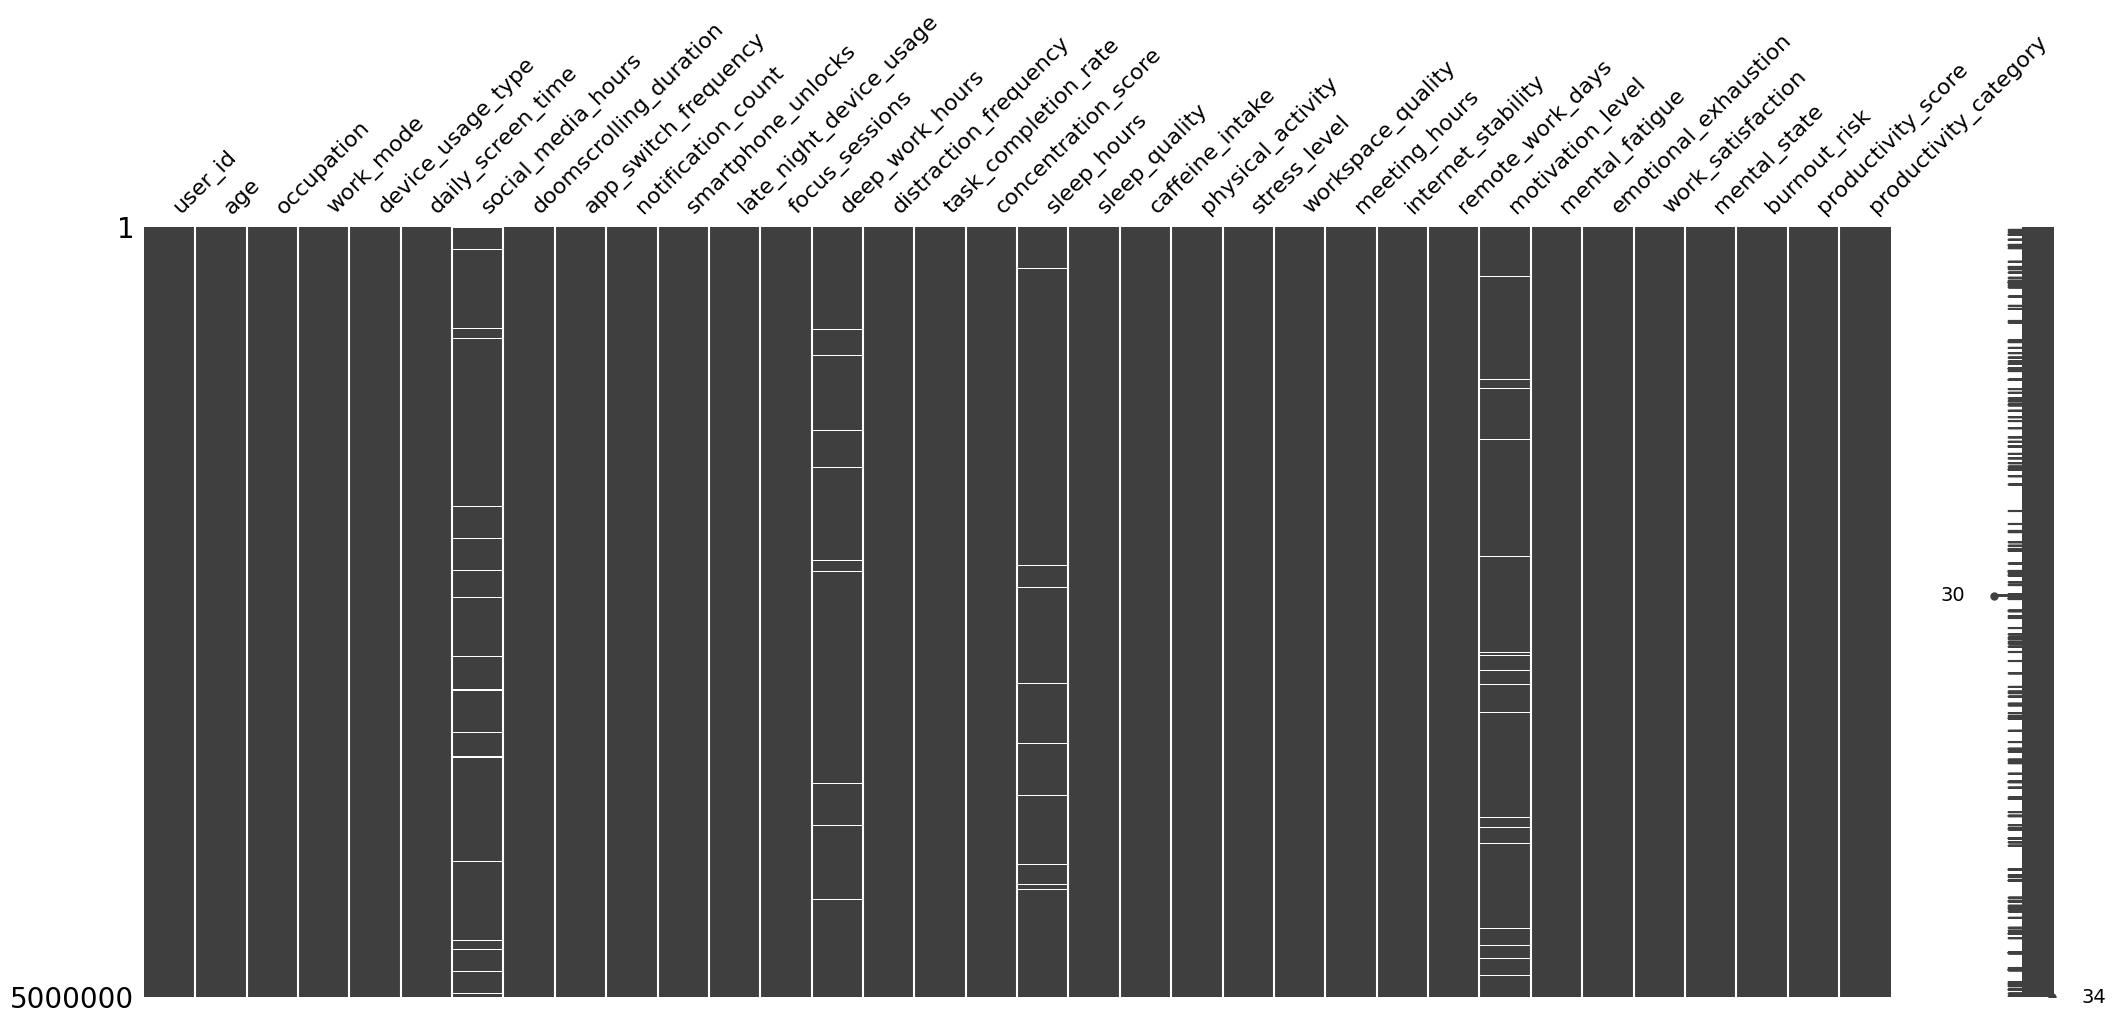

In [165]:
msno.matrix(df.to_pandas())

In [166]:
pdf = df.to_pandas()[['social_media_hours','deep_work_hours',
                      'sleep_hours','motivation_level']]
print(pdf.isna().sum())
print(pdf.dtypes)


social_media_hours    100000
deep_work_hours       100000
sleep_hours           100000
motivation_level      100000
dtype: int64
social_media_hours    float64
deep_work_hours       float64
sleep_hours           float64
motivation_level      float64
dtype: object


<Axes: >

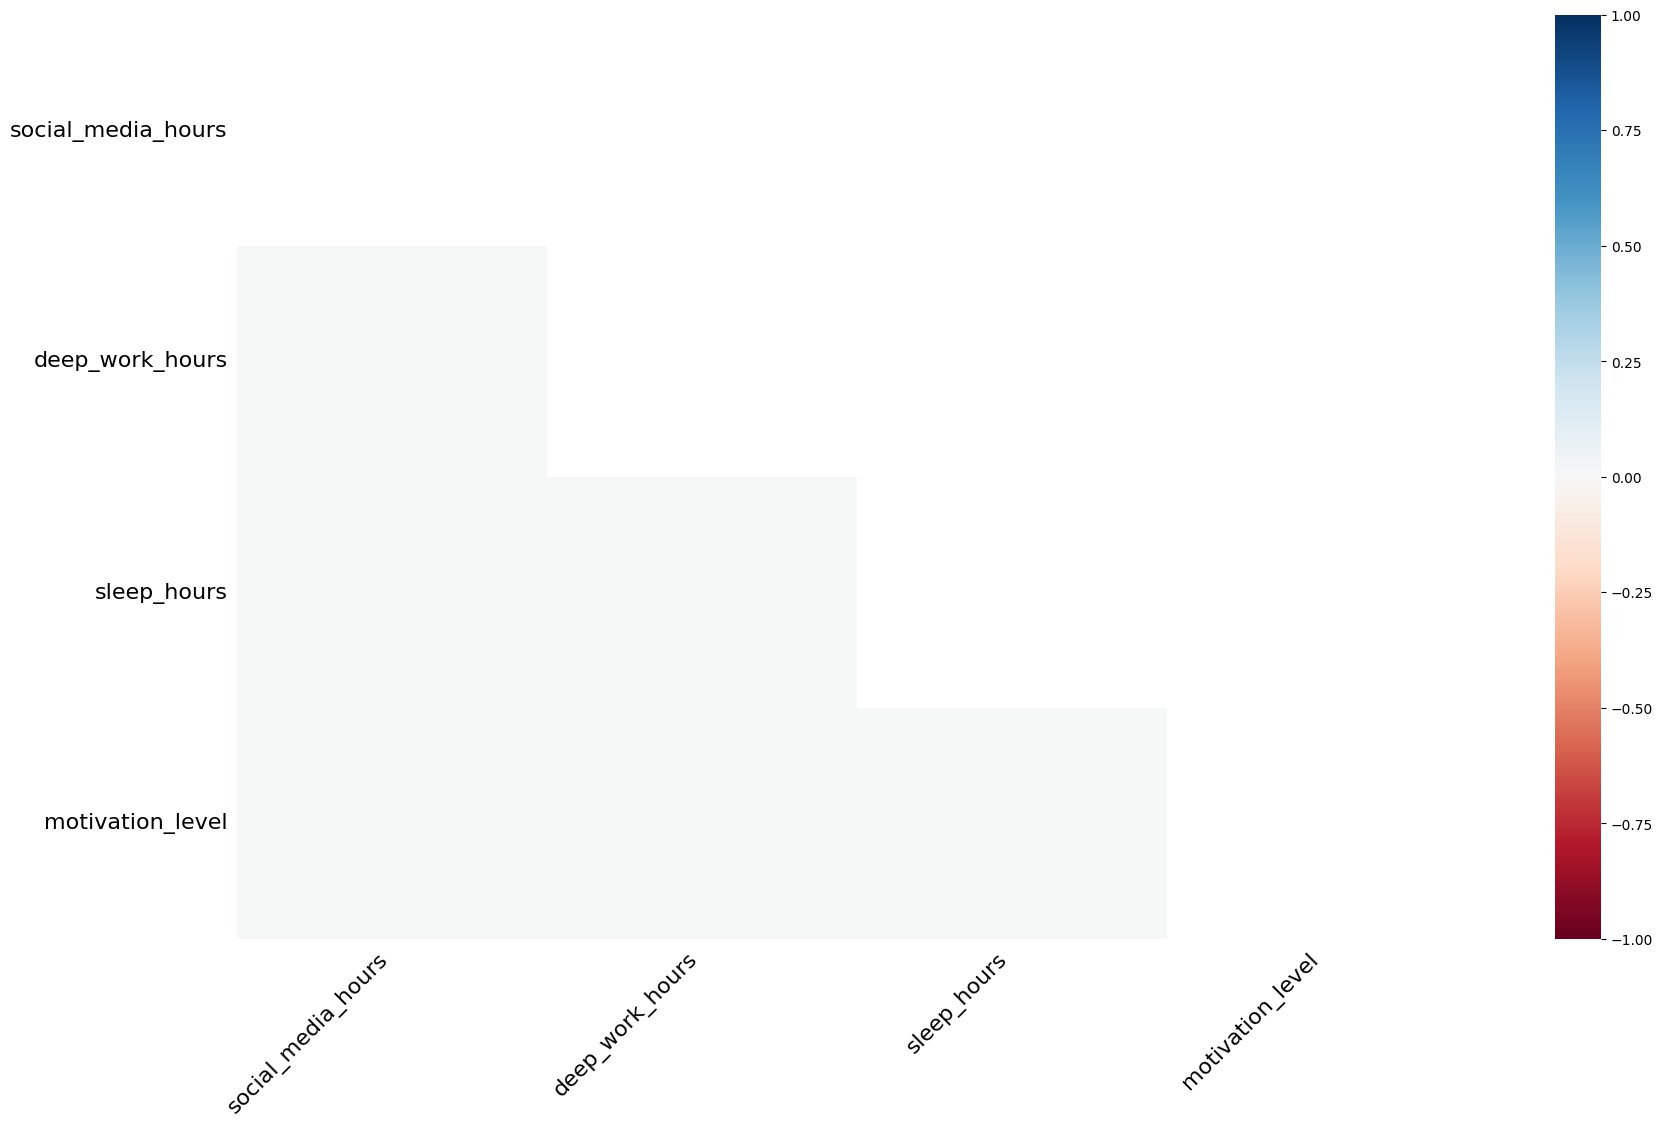

In [167]:
msno.heatmap(pdf)


In [168]:
pdf.corr()

,social_media_hours,deep_work_hours,sleep_hours,motivation_level
social_media_hours,1.00000,-0.00026,-0.00040,-0.00004
deep_work_hours,-0.00026,1.00000,0.00004,0.00008
sleep_hours,-0.00040,0.00004,1.00000,0.00012
motivation_level,-0.00004,0.00008,0.00012,1.00000


In [169]:
num_df = df.select(pl.selectors.numeric())
num_df.corr()


user_id,age,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,burnout_risk,productivity_score
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.00000,-0.00016,0.00042,NaN,0.00018,-0.00064,0.00004,-0.00025,-0.00025,-0.00094,NaN,-0.00032,-0.00004,-0.00026,NaN,0.00010,-0.00001,0.00083,-0.00023,-0.00069,-0.00131,-0.00032,-0.00031,NaN,-0.00027,0.00040,0.00003,0.00008,-0.00064
-0.00016,1.00000,-0.00031,NaN,0.00011,-0.00013,0.00036,0.00034,-0.00002,-0.00041,NaN,0.00023,-0.00047,-0.00068,NaN,-0.00001,-0.00035,-0.00048,0.00038,-0.00035,0.00053,-0.00023,0.00045,NaN,0.00057,0.00088,-0.00042,0.00061,-0.00135
0.00042,-0.00031,1.00000,NaN,-0.00053,-0.00049,-0.00023,-0.00031,-0.00052,0.00057,NaN,-0.00011,-0.00035,-0.00080,NaN,-0.00068,-0.00002,0.00019,-0.00018,0.00041,-0.00054,-0.00052,-0.00075,NaN,-0.00019,0.00064,0.00019,0.22078,-0.07777
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.00018,0.00011,-0.00053,NaN,1.00000,-0.00078,-0.00008,-0.00065,-0.00023,0.00063,NaN,-0.00006,-0.00035,0.00022,NaN,0.00038,-0.00061,0.00016,0.00057,-0.00052,-0.00006,-0.00005,-0.00067,NaN,0.00054,0.00002,0.00034,0.20032,-0.07154
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.00027,0.00057,-0.00019,NaN,0.00054,0.00028,0.00038,0.00035,0.00014,0.00087,NaN,0.00001,0.00098,0.00051,NaN,-0.00019,0.00075,-0.00017,-0.00055,-0.00100,-0.00091,0.00036,-0.00018,NaN,1.00000,0.00022,-0.00007,-0.00012,0.00060
0.00040,0.00088,0.00064,NaN,0.00002,-0.00085,0.00047,-0.00031,-0.00016,-0.00002,NaN,-0.00004,0.00028,-0.00000,NaN,0.00039,-0.00054,-0.00048,0.00048,-0.00014,0.00004,-0.00033,-0.00003,NaN,0.00022,1.00000,-0.00010,0.51198,-0.18194
0.00003,-0.00042,0.00019,NaN,0.00034,-0.00002,0.00026,0.00026,0.00029,-0.00063,NaN,-0.00084,0.00059,0.00109,NaN,-0.00014,-0.00006,-0.00002,0.00010,-0.00074,0.00040,0.00032,-0.00045,NaN,-0.00007,-0.00010,1.00000,-0.25435,0.09054


In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


model = make_pipeline(StandardScaler(with_mean=False), LogisticRegression(max_iter=500))


cols_to_check = ['social_media_hours','deep_work_hours',
                 'sleep_hours','motivation_level']

sample = df.sample(n=200_000, seed=42).to_pandas()

for target_col in cols_to_check:
    y = sample[target_col].isna().astype(int)
    X = sample.drop(columns=[target_col])
    X = pd.get_dummies(X, drop_first=True).fillna(-999)

    auc = cross_val_score(
        LogisticRegression(max_iter=200),
        X, y, scoring='roc_auc', cv=3
    ).mean()
    print(f'{target_col:25s} AUC: {auc:.3f}')


c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

social_media_hours        AUC: 0.504


c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

deep_work_hours           AUC: 0.501


c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

sleep_hours               AUC: 0.507


c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

motivation_level          AUC: 0.505


c:\Users\neovs\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [171]:
cols = ['social_media_hours','deep_work_hours','sleep_hours','motivation_level']
# заполнение пропусков медианой и проставление флагов
for col in cols:
    median_val = df[col].median()
    df = df.with_columns([
        df[col].is_null().cast(pl.Int8).alias(f'{col}_was_missing'),
        df[col].fill_null(median_val),
    ])


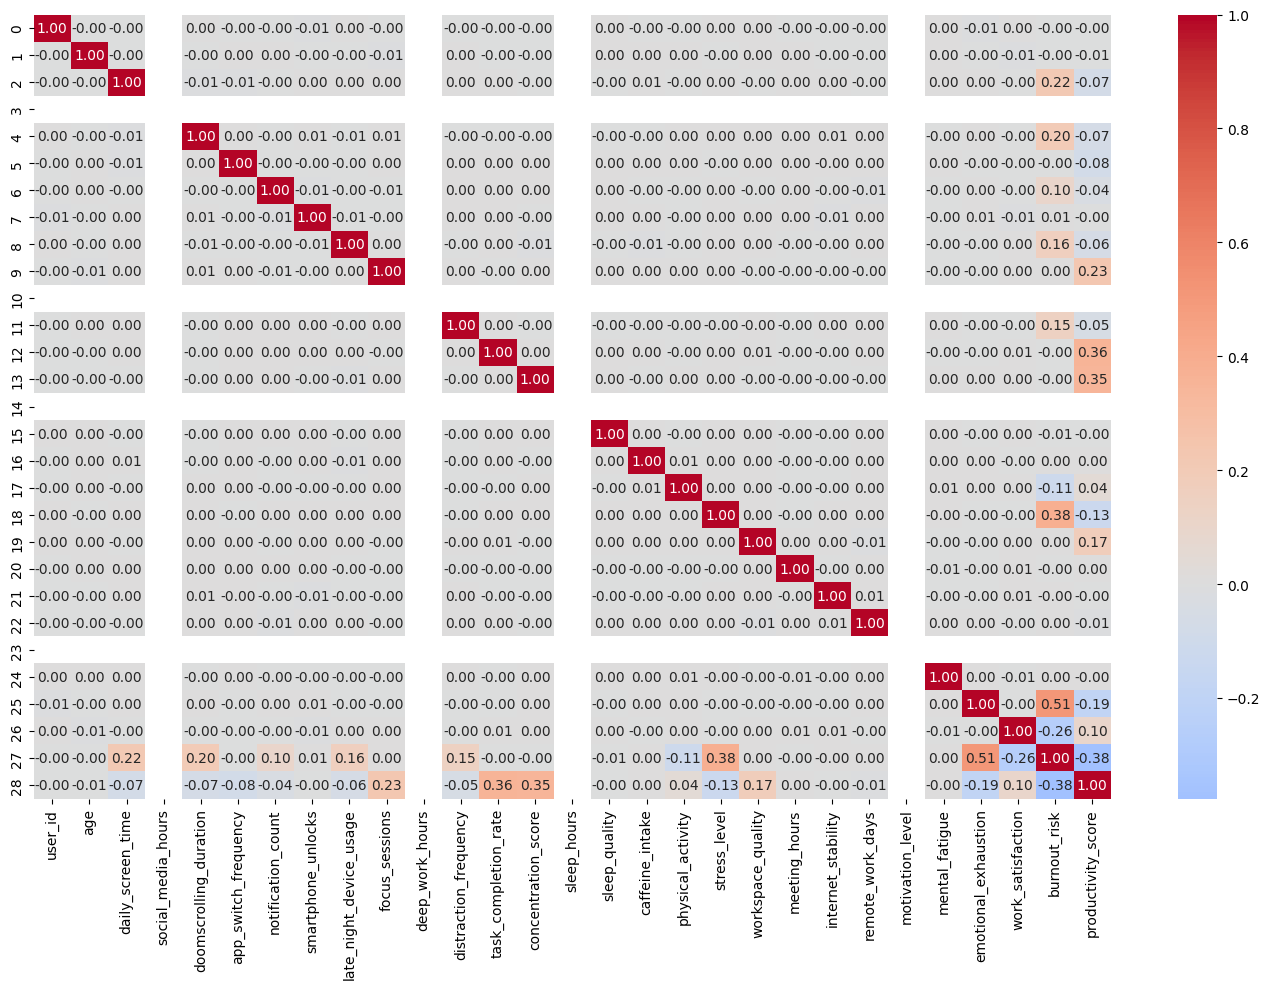

In [172]:
corr = num_df.sample(n=100_000, seed=42).corr().to_pandas()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()


In [173]:
df.sample(10)

user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category,social_media_hours_was_missing,deep_work_hours_was_missing,sleep_hours_was_missing,motivation_level_was_missing
i64,i64,cat,cat,cat,f64,f64,f64,i64,i64,i64,i64,i64,f64,i64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,i64,cat,i64,i64,cat,i8,i8,i8,i8
4764400,46,"""Designer""","""Hybrid""","""Balanced""",6.50000,3.40000,2.40000,188,257,258,0,7,0.00000,18,96,6,8.70000,5,0,1.60000,3,6,0.00000,6,3,5.00000,8,3,4,"""Distracted""",20,81,"""High""",0,0,0,0
4620253,18,"""Content Creator""","""Hybrid""","""Balanced""",10.80000,4.50000,3.20000,95,211,193,1,5,6.60000,25,70,8,5.00000,6,5,1.50000,2,10,1.80000,7,0,5.00000,9,1,10,"""Balanced""",10,100,"""High""",0,0,0,0
2646658,22,"""Software Engineer""","""Remote""","""Balanced""",4.40000,3.90000,3.70000,239,184,272,0,0,2.30000,102,40,2,5.60000,5,4,1.30000,7,5,1.40000,1,4,8.00000,10,7,7,"""Focused""",30,32,"""Low""",0,0,0,0
2294602,39,"""Freelancer""","""Remote""","""Work-Centric""",10.70000,4.60000,2.40000,68,397,261,1,1,1.30000,87,50,10,8.10000,4,7,0.30000,6,9,4.10000,6,2,3.00000,1,4,6,"""Distracted""",58,57,"""Medium""",0,0,0,0
324596,32,"""Student""","""Remote""","""Balanced""",5.80000,6.50000,0.40000,160,392,124,1,5,3.00000,89,85,6,8.40000,3,7,1.10000,9,6,2.50000,7,4,4.00000,3,10,3,"""Distracted""",71,75,"""High""",0,1,0,0
2784121,38,"""Content Creator""","""Remote""","""Balanced""",7.40000,2.00000,2.10000,106,177,281,1,4,0.50000,39,61,4,8.40000,5,4,1.60000,9,2,5.10000,4,1,4.00000,4,10,2,"""Distracted""",57,38,"""Low""",0,0,0,0
724596,47,"""Manager""","""Office""","""Work-Centric""",13.40000,1.90000,3.70000,231,130,250,1,4,5.50000,24,53,6,8.80000,7,3,1.80000,10,4,2.40000,7,3,9.00000,9,7,6,"""Distracted""",74,75,"""High""",0,0,0,0
343149,25,"""Designer""","""Hybrid""","""Work-Centric""",5.30000,4.80000,2.30000,180,39,293,1,8,2.80000,39,95,10,7.20000,3,1,1.00000,4,10,0.80000,1,1,3.00000,1,5,1,"""Distracted""",58,100,"""High""",0,0,0,0
3378071,23,"""Software Engineer""","""Remote""","""Entertainment-Centric""",2.50000,5.70000,1.10000,211,45,77,0,9,6.00000,39,53,4,7.20000,6,4,0.10000,7,10,2.60000,9,5,1.00000,2,10,1,"""Balanced""",36,95,"""High""",0,0,0,0


In [174]:
df_pandas = df.to_pandas()

In [175]:
df_pandas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 38 columns):
 #   Column                          Dtype   
---  ------                          -----   
 0   user_id                         int64   
 1   age                             int64   
 2   occupation                      category
 3   work_mode                       category
 4   device_usage_type               category
 5   daily_screen_time               float64 
 6   social_media_hours              float64 
 7   doomscrolling_duration          float64 
 8   app_switch_frequency            int64   
 9   notification_count              int64   
 10  smartphone_unlocks              int64   
 11  late_night_device_usage         int64   
 12  focus_sessions                  int64   
 13  deep_work_hours                 float64 
 14  distraction_frequency           int64   
 15  task_completion_rate            int64   
 16  concentration_score             int64   
 17  sleep_ho

In [192]:
sample = df_pandas.sample(100000)

X = sample.drop(columns=['user_id', 'mental_state', 'burnout_risk', 'productivity_score', 'productivity_category'])
y = sample['productivity_score'].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)
X_train

,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,social_media_hours_was_missing,deep_work_hours_was_missing,sleep_hours_was_missing,motivation_level_was_missing
305882,37,Designer,Remote,Balanced,2.50000,3.90000,0.20000,14,355,206,1,9,2.00000,118,68,5,7.40000,4,5,0.40000,5,10,2.20000,6,4,8.00000,7,5,10,0,0,0,0
3289390,50,Designer,Hybrid,Entertainment-Centric,8.90000,3.60000,3.20000,42,177,86,1,9,1.70000,49,68,7,4.60000,10,1,3.00000,6,1,1.10000,10,2,9.00000,5,3,2,0,0,0,0
4459864,22,Software Engineer,Remote,Work-Centric,12.60000,2.80000,2.50000,152,217,50,1,5,4.50000,91,76,2,6.80000,1,0,0.00000,9,8,3.80000,4,6,4.00000,4,2,4,0,0,0,0
34326,25,Manager,Remote,Balanced,5.90000,3.90000,1.10000,242,375,40,0,5,3.20000,16,67,3,7.30000,7,2,1.30000,7,2,1.80000,10,3,1.00000,2,7,8,0,0,0,0
4326019,32,Freelancer,Remote,Work-Centric,7.60000,5.30000,1.70000,10,385,80,0,9,5.10000,51,82,6,7.50000,7,7,1.40000,3,5,1.70000,4,3,2.00000,6,8,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157201,43,Manager,Office,Balanced,10.90000,2.00000,1.50000,110,280,290,0,1,4.60000,73,92,1,6.50000,9,6,1.60000,6,10,3.40000,7,3,1.00000,9,8,7,0,0,0,0
2498422,24,Student,Office,Work-Centric,6.30000,5.40000,2.40000,78,175,189,0,6,4.60000,79,61,7,5.90000,6,1,1.00000,2,7,1.00000,5,0,2.00000,3,1,1,0,0,0,0
4690363,34,Manager,Remote,Entertainment-Centric,12.60000,2.40000,3.90000,74,349,202,1,5,3.60000,98,71,2,9.90000,3,5,2.40000,2,6,3.90000,2,3,5.00000,5,1,1,0,0,0,0
168826,41,Software Engineer,Office,Balanced,7.30000,3.40000,0.00000,50,182,92,0,6,3.70000,101,84,3,7.30000,4,6,0.40000,9,10,1.60000,2,5,4.00000,6,8,1,0,0,0,0


## XGboost

In [179]:
import xgboost as xgb

In [205]:
model = xgb.XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.1,
    max_depth = 4,
    colsample_bytree = 0.8,
    enable_categorical = True,
    tree_method = 'hist',
    eval_metric = 'rmse',
    random_state = 1
)

In [206]:
model.fit(X_train, y_train, verbose=True)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [207]:
y_pred = model.predict(X_test)
y_pred

array([86.267235, 31.452412, 84.07275 , ..., 71.4696  , 94.96398 ,
       74.61047 ], dtype=float32)

In [209]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

print(r2_score(y_test, y_pred))
print(root_mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_percentage_error(y_test, y_pred))



0.8146786818487017
9.220424657107028
7.277589778676629
31025306564087.117
